In [90]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

In [92]:
# Load WINE dataset
data = load_wine()
X = data.data
y = data.target

# Seed for reproducibility
np.random.seed(42)


In [94]:
# --- Helper Functions for Decision Tree ---
def gini_index(y):
    """Calculate the Gini index for a target array."""
    _, counts = np.unique(y, return_counts=True)
    prob = counts / len(y)
    return 1 - np.sum(prob ** 2)


In [96]:
def entropy(y):
    """Calculate the entropy for a target array."""
    _, counts = np.unique(y, return_counts=True)
    prob = counts / len(y)
    return -np.sum(prob * np.log2(prob + 1e-6))

In [98]:
def split_data(X, y, feature_idx, threshold):
    """Split the dataset based on a feature and threshold."""
    left_idx = X[:, feature_idx] < threshold
    right_idx = ~left_idx
    return X[left_idx], y[left_idx], X[right_idx], y[right_idx]

In [100]:
def best_split(X, y, criterion):
    """Find the best split based on the chosen criterion."""
    best_gain, best_feature, best_threshold = -1, None, None
    parent_loss = gini_index(y) if criterion == 'gini' else entropy(y)

    for feature_idx in range(X.shape[1]):
        thresholds = np.unique(X[:, feature_idx])
        for threshold in thresholds:
            _, y_left, _, y_right = split_data(X, y, feature_idx, threshold)
            if len(y_left) == 0 or len(y_right) == 0:
                continue

            gain = information_gain(y, y_left, y_right, parent_loss)
            if gain > best_gain:
                best_gain = gain
                best_feature = feature_idx
                best_threshold = threshold

    return best_feature, best_threshold

In [102]:
def information_gain(y, y_left, y_right, parent_loss):
    """Calculate the information gain after a split."""
    weight_left = len(y_left) / len(y)
    weight_right = len(y_right) / len(y)
    loss_left = gini_index(y_left)
    loss_right = gini_index(y_right)
    return parent_loss - (weight_left * loss_left + weight_right * loss_right)

In [104]:
def grow_tree(X, y, depth, max_depth, criterion):
    """Recursively build the decision tree."""
    if depth >= max_depth or len(np.unique(y)) == 1:
        return np.argmax(np.bincount(y))

    feature_idx, threshold = best_split(X, y, criterion)
    if feature_idx is None:
        return np.argmax(np.bincount(y))

    X_left, y_left, X_right, y_right = split_data(X, y, feature_idx, threshold)
    left_tree = grow_tree(X_left, y_left, depth + 1, max_depth, criterion)
    right_tree = grow_tree(X_right, y_right, depth + 1, max_depth, criterion)

    return (feature_idx, threshold, left_tree, right_tree)

In [106]:
def predict_tree(tree, x):
    """Predict the label for a single instance using a trained decision tree."""
    if isinstance(tree, (int, np.integer)):
        return tree

    feature_idx, threshold, left, right = tree
    if x[feature_idx] < threshold:
        return predict_tree(left, x)
    else:
        return predict_tree(right, x)

In [108]:
# --- Random Forest and Extra Trees Functions ---
def fit_forest(X, y, n_trees, max_depth, criterion, extra_trees=False):
    """Train a Random Forest or Extra Trees model."""
    trees = []
    for _ in range(n_trees):
        indices = np.random.choice(len(X), len(X), replace=True)
        X_sample, y_sample = X[indices], y[indices]

        if extra_trees:
            feature_idx = np.random.choice(X.shape[1])
            X_sample = X_sample[:, feature_idx].reshape(-1, 1)

        tree = grow_tree(X_sample, y_sample, 0, max_depth, criterion)
        trees.append(tree)

    return trees

In [112]:
def predict_forest(trees, X):
    """Predict the labels for a dataset using an ensemble of trees."""
    predictions = np.array([np.array([predict_tree(tree, x) for x in X]) for tree in trees])
    return np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=predictions)

In [136]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import KFold
import numpy as np

# --- Evaluation Function ---
def evaluate_model(X, y, n_trees, max_depth, criterion, extra_trees=False):
    """Evaluate the model using k-fold cross-validation."""
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    accuracies, f1_scores = [], []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Train and predict
        trees = fit_forest(X_train, y_train, n_trees, max_depth, criterion, extra_trees)
        y_pred = predict_forest(trees, X_test)

        print(f"Fold {fold}:")
        for class_label in np.unique(y):
            count = np.sum(y_pred == class_label)
            print(f"  Class {class_label}: {count} ")

        # Store evaluation metrics
        accuracies.append(accuracy_score(y_test, y_pred))
        f1_scores.append(f1_score(y_test, y_pred, average='weighted'))

    return np.mean(accuracies), np.mean(f1_scores)


In [138]:
# --- Hyperparameters ---
n_trees_list = [5, 10, 20]
max_depth_list = [3, 5, 10]
criterion = 'gini'

In [140]:
# --- Store Results ---
results = {'n_trees': [], 'max_depth': [], 'RF_Accuracy': [], 'RF_F1': [], 'ETC_Accuracy': [], 'ETC_F1': []}

In [142]:
# --- Train and Evaluate Models ---
for n_trees in n_trees_list:
    for max_depth in max_depth_list:
        rf_acc, rf_f1 = evaluate_model(X, y, n_trees, max_depth, criterion, extra_trees=False)
        etc_acc, etc_f1 = evaluate_model(X, y, n_trees, max_depth, criterion, extra_trees=True)

        results['n_trees'].append(n_trees)
        results['max_depth'].append(max_depth)
        results['RF_Accuracy'].append(rf_acc)
        results['RF_F1'].append(rf_f1)
        results['ETC_Accuracy'].append(etc_acc)
        results['ETC_F1'].append(etc_f1)

Fold 1:
  Class 0: 13 
  Class 1: 16 
  Class 2: 7 
Fold 2:
  Class 0: 7 
  Class 1: 18 
  Class 2: 11 
Fold 3:
  Class 0: 9 
  Class 1: 22 
  Class 2: 5 
Fold 4:
  Class 0: 11 
  Class 1: 12 
  Class 2: 12 
Fold 5:
  Class 0: 10 
  Class 1: 15 
  Class 2: 10 
Fold 1:
  Class 0: 36 
  Class 1: 0 
  Class 2: 0 
Fold 2:
  Class 0: 36 
  Class 1: 0 
  Class 2: 0 
Fold 3:
  Class 0: 0 
  Class 1: 0 
  Class 2: 36 
Fold 4:
  Class 0: 35 
  Class 1: 0 
  Class 2: 0 
Fold 5:
  Class 0: 35 
  Class 1: 0 
  Class 2: 0 
Fold 1:
  Class 0: 13 
  Class 1: 15 
  Class 2: 8 
Fold 2:
  Class 0: 10 
  Class 1: 15 
  Class 2: 11 
Fold 3:
  Class 0: 10 
  Class 1: 17 
  Class 2: 9 
Fold 4:
  Class 0: 11 
  Class 1: 12 
  Class 2: 12 
Fold 5:
  Class 0: 11 
  Class 1: 15 
  Class 2: 9 
Fold 1:
  Class 0: 0 
  Class 1: 36 
  Class 2: 0 
Fold 2:
  Class 0: 0 
  Class 1: 36 
  Class 2: 0 
Fold 3:
  Class 0: 0 
  Class 1: 36 
  Class 2: 0 
Fold 4:
  Class 0: 0 
  Class 1: 35 
  Class 2: 0 
Fold 5:
  Class 0:

   n_trees  max_depth  RF_Accuracy     RF_F1  ETC_Accuracy    ETC_F1
0        5          3     0.932540  0.932705      0.331429  0.166121
1        5          5     0.937937  0.937854      0.415238  0.268358
2        5         10     0.949365  0.949751      0.348730  0.182841
3       10          3     0.960794  0.960995      0.477619  0.362819
4       10          5     0.960476  0.960542      0.438730  0.282926
5       10         10     0.955238  0.955192      0.450159  0.307133
6       20          3     0.960794  0.960362      0.568571  0.435663
7       20          5     0.960635  0.960724      0.459841  0.322383
8       20         10     0.977460  0.977445      0.398730  0.228417


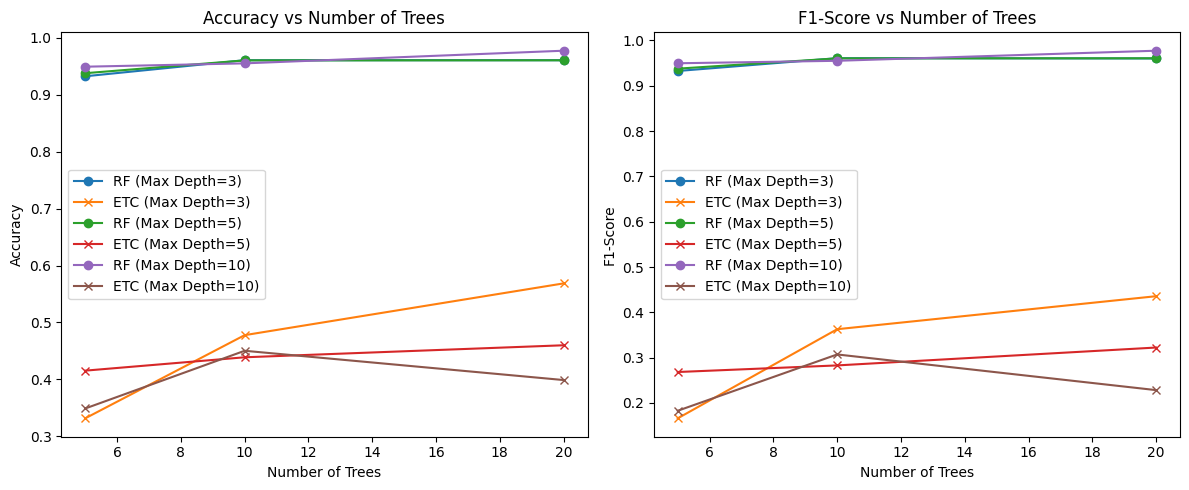

In [49]:
# --- Convert Results to DataFrame ---
results_df = pd.DataFrame(results)

# Verify the DataFrame
print(results_df)

# --- Plot Results ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Accuracy vs Number of Trees for Random Forest and Extra Trees
for max_depth in max_depth_list:
    rf_data = results_df[results_df['max_depth'] == max_depth]
    axes[0].plot(
        rf_data['n_trees'], rf_data['RF_Accuracy'], label=f'RF (Max Depth={max_depth})', marker='o'
    )
    axes[0].plot(
        rf_data['n_trees'], rf_data['ETC_Accuracy'], label=f'ETC (Max Depth={max_depth})', marker='x'
    )

axes[0].set_title('Accuracy vs Number of Trees')
axes[0].set_xlabel('Number of Trees')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Plot F1-Score vs Number of Trees for Random Forest and Extra Trees
for max_depth in max_depth_list:
    rf_data = results_df[results_df['max_depth'] == max_depth]
    axes[1].plot(
        rf_data['n_trees'], rf_data['RF_F1'], label=f'RF (Max Depth={max_depth})', marker='o'
    )
    axes[1].plot(
        rf_data['n_trees'], rf_data['ETC_F1'], label=f'ETC (Max Depth={max_depth})', marker='x'
    )

axes[1].set_title('F1-Score vs Number of Trees')
axes[1].set_xlabel('Number of Trees')
axes[1].set_ylabel('F1-Score')
axes[1].legend()

plt.tight_layout()
plt.show()



In [ ]:
# --- Convert Results to DataFrame ---
results_df = pd.DataFrame(results)

# Verify the DataFrame
print(results_df)

# --- Plot Results ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Accuracy vs Number of Trees for Random Forest and Extra Trees
for max_depth in max_depth_list:
    rf_data = results_df[results_df['max_depth'] == max_depth]
    axes[0].plot(
        rf_data['n_trees'], rf_data['RF_Accuracy'], label=f'RF (Max Depth={max_depth})', marker='o'
    )
    axes[0].plot(
        rf_data['n_trees'], rf_data['ETC_Accuracy'], label=f'ETC (Max Depth={max_depth})', marker='x'
    )

axes[0].set_title('Accuracy vs Number of Trees')
axes[0].set_xlabel('Number of Trees')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Plot F1-Score vs Number of Trees for Random Forest and Extra Trees
for max_depth in max_depth_list:
    rf_data = results_df[results_df['max_depth'] == max_depth]
    axes[1].plot(
        rf_data['n_trees'], rf_data['RF_F1'], label=f'RF (Max Depth={max_depth})', marker='o'
    )
    axes[1].plot(
        rf_data['n_trees'], rf_data['ETC_F1'], label=f'ETC (Max Depth={max_depth})', marker='x'
    )

axes[1].set_title('F1-Score vs Number of Trees')
axes[1].set_xlabel('Number of Trees')
axes[1].set_ylabel('F1-Score')
axes[1].legend()

plt.tight_layout()
plt.show()
